# Insulin Resistance Prediction
**Dataset:** health_dataset_200k_real_countries.csv  
**Target:** Insulin_Resistant (0 = No, 1 = Yes)

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, pickle
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

## 1. Load Data

In [21]:
df = pd.read_csv('health_dataset_200k_real_countries.csv')
df.columns = df.columns.str.strip()
print(df.shape)
df.head()

(190000, 16)


,ID,Country,Year,Age,Gender,Age_Group,HbA1c,HDL,LDL,TG,TG_HDL_Ratio,Fasting_Insulin,HOMA_IR,Diabetic,Insulin_Resistant,Heart_Risk
0,1,United States,2005,67,Female,Elderly,7.32,45.24,120.60,135.67,3.00,8.95,2.19,1,0,Low
1,2,United States,2005,64,Female,Elderly,7.09,38.66,186.41,226.44,5.86,10.55,2.58,1,1,High
2,3,United States,2005,28,Male,Adult,7.56,41.43,184.71,162.73,3.93,9.41,2.30,1,0,High
3,4,United States,2005,8,Male,Child,5.88,26.34,165.12,229.17,8.70,12.75,3.12,0,1,High
4,5,United States,2005,11,Female,Child,7.55,60.34,109.07,182.53,3.03,8.22,2.01,1,0,Low


## 2. EDA

In [22]:
print(df.dtypes)
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

ID                     int64
Country                  str
Year                   int64
Age                    int64
Gender                   str
Age_Group                str
HbA1c                float64
HDL                  float64
LDL                  float64
TG                   float64
TG_HDL_Ratio         float64
Fasting_Insulin      float64
HOMA_IR              float64
Diabetic               int64
Insulin_Resistant      int64
Heart_Risk               str
dtype: object
Missing values:
 ID                   0
Country              0
Year                 0
Age                  0
Gender               0
Age_Group            0
HbA1c                0
HDL                  0
LDL                  0
TG                   0
TG_HDL_Ratio         0
Fasting_Insulin      0
HOMA_IR              0
Diabetic             0
Insulin_Resistant    0
Heart_Risk           0
dtype: int64
Duplicates: 0


In [23]:
df.describe()

,ID,Year,Age,HbA1c,HDL,LDL,TG,TG_HDL_Ratio,Fasting_Insulin,HOMA_IR,Diabetic,Insulin_Resistant
count,190000.00000,190000.000000,190000.000000,190000.000000,190000.000000,190000.000000,190000.000000,190000.000000,190000.000000,190000.000000,190000.000000,190000.000000
mean,95000.50000,2014.500000,42.988958,6.890296,45.698339,140.161147,170.608480,3.978544,7.729455,1.889421,0.630037,0.215663
std,54848.41991,5.766296,24.535777,1.175041,10.288611,26.732741,51.808335,1.869965,3.167163,0.774188,0.482796,0.411283
min,1.00000,2005.000000,1.000000,1.400000,-5.540000,18.230000,-66.280000,-29.260000,-6.870000,-1.680000,0.000000,0.000000
25%,47500.75000,2009.750000,22.000000,6.100000,38.760000,122.090000,135.520000,2.840000,5.580000,1.370000,0.000000,0.000000
50%,95000.50000,2014.500000,43.000000,6.890000,45.700000,140.150000,170.730000,3.740000,7.730000,1.890000,1.000000,0.000000
75%,142500.25000,2019.250000,64.000000,7.690000,52.660000,158.290000,205.560000,4.810000,9.870000,2.410000,1.000000,0.000000
max,190000.00000,2024.000000,85.000000,11.820000,90.660000,255.060000,410.050000,311.470000,21.990000,5.370000,1.000000,1.000000


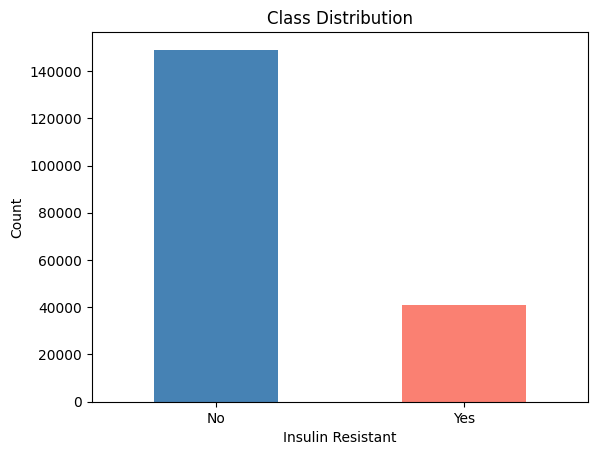

In [24]:
# Target distribution
df['Insulin_Resistant'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Class Distribution')
plt.xlabel('Insulin Resistant')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.show()

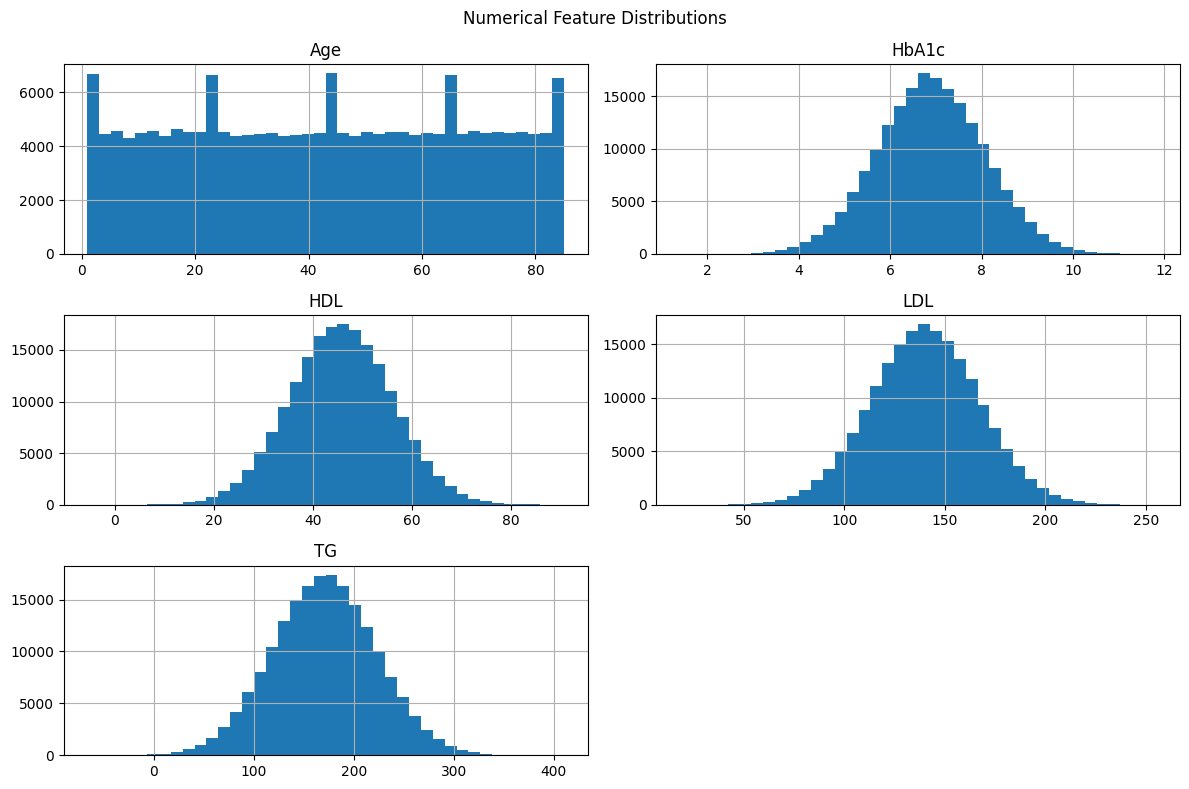

In [25]:
# Numerical feature distributions
num_cols = ['Age', 'HbA1c', 'HDL', 'LDL', 'TG']
df[num_cols].hist(figsize=(12, 8), bins=40)
plt.suptitle('Numerical Feature Distributions')
plt.tight_layout()
plt.show()

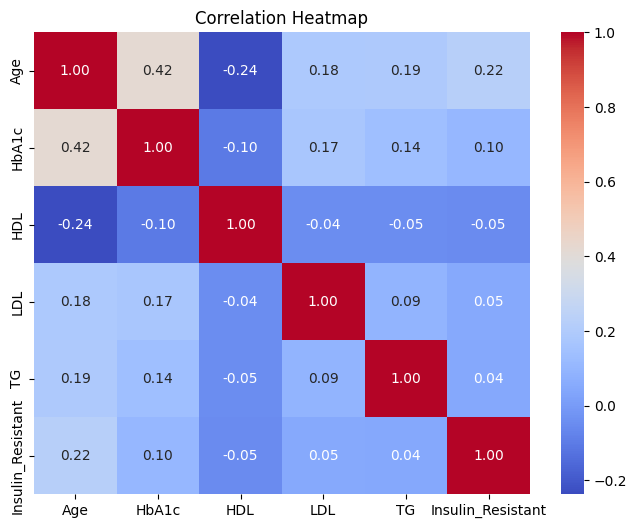

In [26]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols + ['Insulin_Resistant']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 3. Preprocessing

**Note on leaky features:** HOMA_IR, Fasting_Insulin, TG_HDL_Ratio, and Diabetic are removed because they either directly encode the target label or are near-perfect proxies for it, causing all models to score AUC = 1.0.

In [27]:
from sklearn.preprocessing import LabelEncoder

ENCODE_COLS = ['Country', 'Gender', 'Age_Group', 'Heart_Risk']
df_enc = df.copy()
label_encoders = {}

for col in ENCODE_COLS:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    label_encoders[col] = le

# Save all encoders in one file
with open('encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

print('Label encoding done')

Label encoding done


In [28]:
LEAKY_FEATURES = ['HOMA_IR', 'Fasting_Insulin', 'TG_HDL_Ratio', 'Diabetic']
X = df_enc.drop(columns=['ID', 'Insulin_Resistant'] + LEAKY_FEATURES)
y = df_enc['Insulin_Resistant']

print('Features:', X.columns.tolist())
print('Shape:', X.shape)

Features: ['Country', 'Year', 'Age', 'Gender', 'Age_Group', 'HbA1c', 'HDL', 'LDL', 'TG', 'Heart_Risk']
Shape: (190000, 10)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]}  Test: {X_test.shape[0]}')

Train: 152000  Test: 38000


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

## 4. SMOTE — Handle Class Imbalance

Applied only on training data. Test set is never touched.

In [31]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print(f'Before SMOTE: {dict(y_train.value_counts())}')
print(f'After  SMOTE: {dict(pd.Series(y_train_sm).value_counts())}')

Before SMOTE: {0: np.int64(119219), 1: np.int64(32781)}
After  SMOTE: {0: np.int64(119219), 1: np.int64(119219)}


## 5. Model Training

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score

models = {
    'KNN':                 KNeighborsClassifier(n_neighbors=7),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=12, random_state=RANDOM_STATE),
    'XGBoost':             XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0),
}

In [40]:
# 5-Fold Stratified Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f'{"Model":<22} {"Accuracy":>10} {"Precision":>10} {"Recall":>8} {"F1":>8} {"ROC-AUC":>10}')
print('-' * 70)

for name, model in models.items():
    cv = cross_validate(model, X_train_sm, y_train_sm, cv=skf,
                        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
    print(f'{name:<22} {cv["test_accuracy"].mean():>10.4f} {cv["test_precision"].mean():>10.4f} {cv["test_recall"].mean():>8.4f} {cv["test_f1"].mean():>8.4f} {cv["test_roc_auc"].mean():>10.4f}')

Model                    Accuracy  Precision   Recall       F1    ROC-AUC
----------------------------------------------------------------------
KNN                        0.7328     0.6768   0.8913   0.7694     0.8277
Logistic Regression        0.6189     0.6114   0.6525   0.6313     0.6577
Decision Tree              0.6677     0.6555   0.7079   0.6805     0.7303
Random Forest              0.6864     0.6758   0.7166   0.6956     0.7617
XGBoost                    0.8072     0.9537   0.6458   0.7701     0.8693


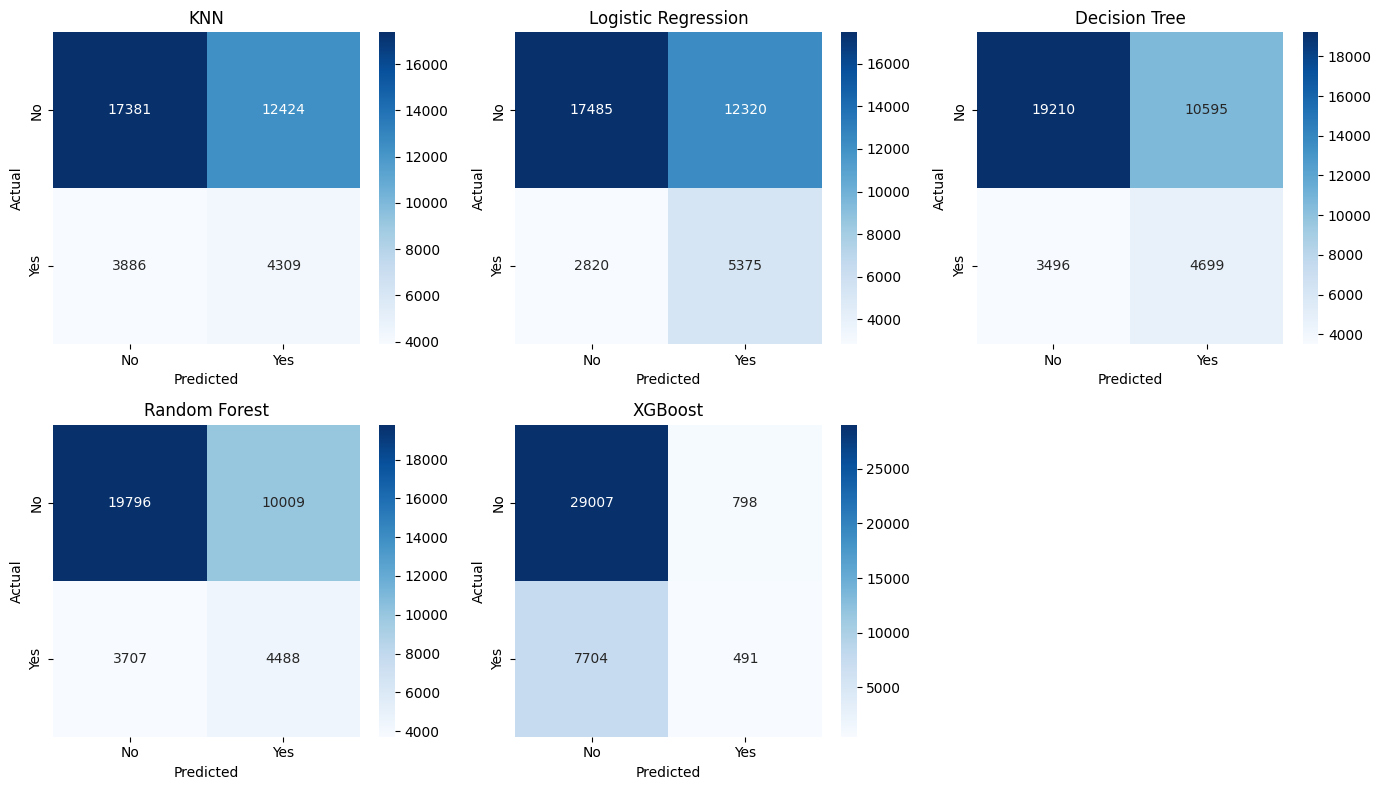

In [35]:
# Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes_flat = list(axes.flat)

for i, (name, model) in enumerate(models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test_sc))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_flat[i],
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    axes_flat[i].set_title(name)
    axes_flat[i].set_xlabel('Predicted')
    axes_flat[i].set_ylabel('Actual')

axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

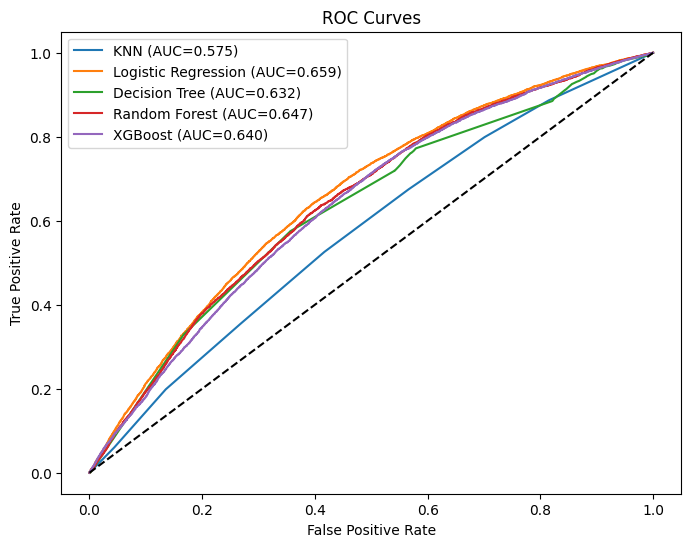

In [36]:
# ROC Curves
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

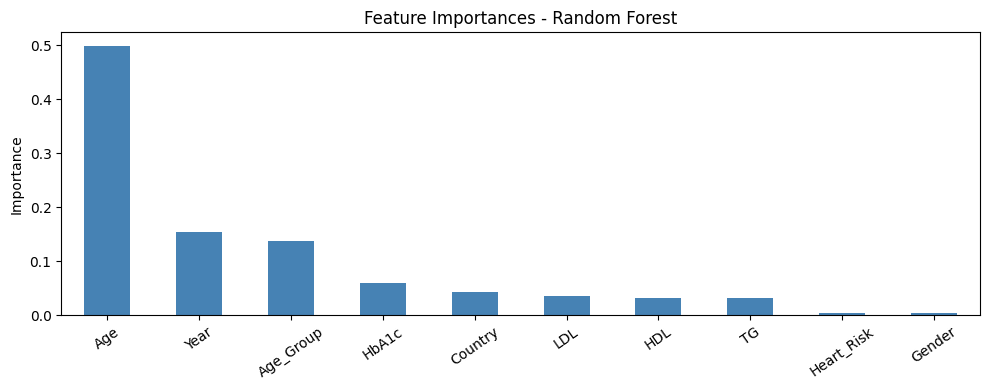

In [37]:
# Feature Importances (Random Forest)
rf = models['Random Forest']
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(10, 4), color='steelblue')
plt.title('Feature Importances - Random Forest')
plt.ylabel('Importance')
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

## 6. Save Best Model

In [38]:
best_model = models['Random Forest']
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print('Saved model.pkl')

Saved model.pkl
